You need to do the followig before you run the code
- Change the user agent variable in the following code block.
- If you want to create a sub-index using the LLM, you need to add the API KEY of OpenAI or some other language model.
- The output paths need to be defined.
- A directory will be created when you run section 1 of this code containing the data. You need to use data/processed/ixbrl_cleaned.csv
### You will need to defined the files such as cdli_csv_path, rates file, fx_path containing the relevant returns.
### Final Data.zip contains these files for reference of their structure.

In [1]:
user_agent = "Your_Name your.email@domain.com"
API_KEY = None
OUTPUT_PATH_LLM = "data/processed/data_private_credit_FINAL_enriched.csv"
OUTPUT_PATH = "data/processed/ixbrl_cleaned_out.csv"
cols = ["cik","investment_identifier","cal_q","FV", "COST", "PAR", "rate_cash", "interest_rate", "rate_pik"]
cols_llm = ["cik","investment_identifier","cal_q","FV", "COST", "PAR", "rate_cash", "interest_rate", "rate_pik","sector","instrument_seniority"]
interest_cols = ["rate_cash", "interest_rate", "rate_pik"]
cdli_csv_path = "data/processed/cdli.csv"
cdli_s_csv_path = "data/processed/cdli-s.csv"
rates_file = "data/processed/Search.xlsx"
data_path = "data/processed/ixbrl_clean.csv"
fx_path = "data/processed/FX.csv"
sofr_path = "data/processed/SOFR.csv"
flag_llm = True


In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]  # 2026 Extension/
sys.path.append(str(ROOT / "src"))
sys.path.append(str(ROOT / "scripts"))


In [2]:
from __future__ import annotations
import sys
from pathlib import Path
from run_bdc_universe import run_bdc_universe
from run_downloader import run_download
from run_ixbrl_parser import run_ixbrl_parse
from run_preprocessor import main as run_preprocess_main
from index_construction import *
from run_ixbrl_pipeline import *
from get_seniority_debttype import *

## Download the Data using SEC Edgar API
### Refer to README_1.md

In [4]:
# Skipped: universe already completed in a prior session; reusing existing files.


In [5]:
# Skipped: download already completed in a prior session; reusing existing files.


In [6]:
# Skipped: ixbrl parse already completed in a prior session; reusing existing files.


In [7]:
# Skipped: preprocess already completed in a prior session; reusing existing files.


## Cleaning the data
### Refer to README_2.MD

In [8]:
# Skipped: cleaning pipeline already run in a prior session; OUTPUT_PATH already exists.


## Adding the Sector and Seniority using LLM(OpenAI)
### Refer to README_3.MD
#### You do not need to run this section if you are trying to construct the main index. 
#### You only need this for the Senior Loans/ Sector Index

In [9]:
# Skipped: seniority/sector enrichment already completed in a prior session (via Claude); OUTPUT_PATH_LLM already exists.


## Index Construction Process
### Refer to README_4.MD

In [10]:
if flag_llm:
    df = load_and_prepare_investment_data(
        OUTPUT_PATH_LLM
    )
    df = df.select(cols_llm)
else:
    df = load_and_prepare_investment_data(
        OUTPUT_PATH
    )
    df = df.select(cols)
df.head()

cik,investment_identifier,cal_q,FV,COST,PAR,rate_cash,interest_rate,rate_pik,sector,instrument_seniority
i64,str,str,f64,f64,f64,f64,f64,f64,str,str
845385,"""Control Investments - Advantis…","""2025Q3""",3.767702e6,null,4.5e6,0.12,0.12,null,"""Consumer""","""SENIOR_SECURED_2L"""
845385,"""Control Investments - PCC SBH …","""2025Q3""",100000.0,null,100000.0,0.1,0.1,null,"""Other / Unknown / Unresolved""","""SENIOR_SECURED_1L"""
845385,"""Control Investments - Rockfish…","""2025Q3""",5.148146e6,null,6.352944e6,0.02,0.08,0.06,"""Consumer""","""SENIOR_SECURED_1L"""
845385,"""Control Investments - Rockfish…","""2025Q3""",2.251e6,null,2.251e6,0.08,0.08,null,"""Consumer""","""OTHER_UNKNOWN"""
845385,"""Control Investments - Advantis…","""2025Q2""",3.822263e6,null,4.5e6,0.12,0.12,null,"""Consumer""","""SENIOR_SECURED_2L"""


In [11]:
missing_summary_pd = missing_percentage_summary(df, cols)
missing_summary_pd

,cik_missing,investment_identifier_missing,cal_q_missing,FV_missing,COST_missing,PAR_missing,rate_cash_missing,interest_rate_missing,rate_pik_missing
0,0.0,0.0,0.0,0.0,1.765159,2.773976,83.18696,3.90491,90.278178


In [12]:
rate_combinations_pd = interest_rate_null_combinations(df, interest_cols)
rate_combinations_pd

,rate_cash_isnull,interest_rate_isnull,rate_pik_isnull,rows
0,False,False,False,29903
1,False,False,True,39304
2,False,True,False,6178
3,False,True,True,2129
4,True,False,False,1239
5,True,False,True,372586
6,True,True,False,7501
7,True,True,True,2195


In [13]:
df = compute_final_interest_rates(df)
df.head()

cik,investment_identifier,cal_q,FV,COST,PAR,rate_cash,interest_rate,rate_pik,sector,instrument_seniority,PIC_Final,PIK_Final,IR_Final
i64,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64
845385,"""Control Investments - Advantis…","""2025Q3""",3.767702e6,null,4.5e6,0.12,0.12,null,"""Consumer""","""SENIOR_SECURED_2L""",0.12,0.0,0.12
845385,"""Control Investments - PCC SBH …","""2025Q3""",100000.0,null,100000.0,0.1,0.1,null,"""Other / Unknown / Unresolved""","""SENIOR_SECURED_1L""",0.1,0.0,0.1
845385,"""Control Investments - Rockfish…","""2025Q3""",5.148146e6,null,6.352944e6,0.02,0.08,0.06,"""Consumer""","""SENIOR_SECURED_1L""",0.02,0.06,0.08
845385,"""Control Investments - Rockfish…","""2025Q3""",2.251e6,null,2.251e6,0.08,0.08,null,"""Consumer""","""OTHER_UNKNOWN""",0.08,0.0,0.08
845385,"""Control Investments - Advantis…","""2025Q2""",3.822263e6,null,4.5e6,0.12,0.12,null,"""Consumer""","""SENIOR_SECURED_2L""",0.12,0.0,0.12


In [14]:
df = compute_position_level_flows(
    df,
    qsort_expr=qsort_expr,
    safe_div=safe_div
)
df.head()

cik,investment_identifier,cal_q,FV,COST,PAR,rate_cash,interest_rate,rate_pik,sector,instrument_seniority,PIC_Final,PIK_Final,IR_Final,qsort,FV_prev,COST_prev,dFV,dCOST,cash_income,pik_income,ret_pos_flow
i64,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q1""",3e6,3e6,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8105,null,null,null,null,97500.0,0.0,0.0
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q2""",3e6,3e6,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8106,3e6,3e6,0.0,0.0,97500.0,0.0,0.0325
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q1""",3e6,null,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8105,null,null,null,null,97500.0,0.0,0.0
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q2""",3e6,null,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8106,null,null,null,null,97500.0,0.0,0.0
81955,"""Applied Image, Inc. - $1,750,0…","""2023Q1""",1.75e6,1.75e6,null,0.1,0.1,null,"""Technology""","""OTHER_UNKNOWN""",0.1,0.0,0.1,8093,null,null,null,null,0.0,0.0,0.0


In [15]:
quarter_distribution = quarter_count_distribution(df)
quarter_distribution

num_quarters,count,proportion
u32,u32,f64
1,160883,0.680125
2,29674,0.125445
3,16944,0.07163
4,7575,0.032023
5,6417,0.027128
…,…,…
10,1737,0.007343
11,1847,0.007808
12,427,0.001805


In [16]:
quarterly_summary = quarterly_cik_entry_exit_aum(df)
quarterly_summary

cal_q,aum_in_m_cik,unique_cik_in,aum_out_m_cik,unique_cik_out
str,f64,u32,f64,u32
"""2023Q1""",557038.62,96,174.5,1
"""2023Q2""",3776.26,9,15.05,1
"""2023Q3""",13046.39,16,3233.9,2
"""2023Q4""",1167.55,8,600.2,1
"""2024Q1""",890.07,6,3666.46,2
…,…,…,…,…
"""2025Q1""",2077.54,5,149.97,1
"""2025Q2""",5898.99,15,3798.16,3
"""2025Q3""",2003.73,5,350.06,1


In [17]:
df = compute_market_weights(df, safe_div=safe_div)
df.head()

cik,investment_identifier,cal_q,FV,COST,PAR,rate_cash,interest_rate,rate_pik,sector,instrument_seniority,PIC_Final,PIK_Final,IR_Final,qsort,FV_prev,COST_prev,dFV,dCOST,cash_income,pik_income,ret_pos_flow,is_valid,FV_prev_sum_q,w_mkt
i64,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q1""",3e6,3e6,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8105,null,null,null,null,97500.0,0.0,0.0,null,2.7930e11,0.0
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q2""",3e6,3e6,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8106,3e6,3e6,0.0,0.0,97500.0,0.0,0.0325,true,1.7389e11,0.000017
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q1""",3e6,null,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8105,null,null,null,null,97500.0,0.0,0.0,null,2.7930e11,0.0
81955,"""AME Holdco, LLC - $3,000,000 T…","""2026Q2""",3e6,null,3e6,0.13,0.13,null,"""Other / Unknown / Unresolved""","""OTHER_UNKNOWN""",0.13,0.0,0.13,8106,null,null,null,null,97500.0,0.0,0.0,null,1.7389e11,0.0
81955,"""Applied Image, Inc. - $1,750,0…","""2023Q1""",1.75e6,1.75e6,null,0.1,0.1,null,"""Technology""","""OTHER_UNKNOWN""",0.1,0.0,0.1,8093,null,null,null,null,0.0,0.0,0.0,null,3.5841e9,0.0


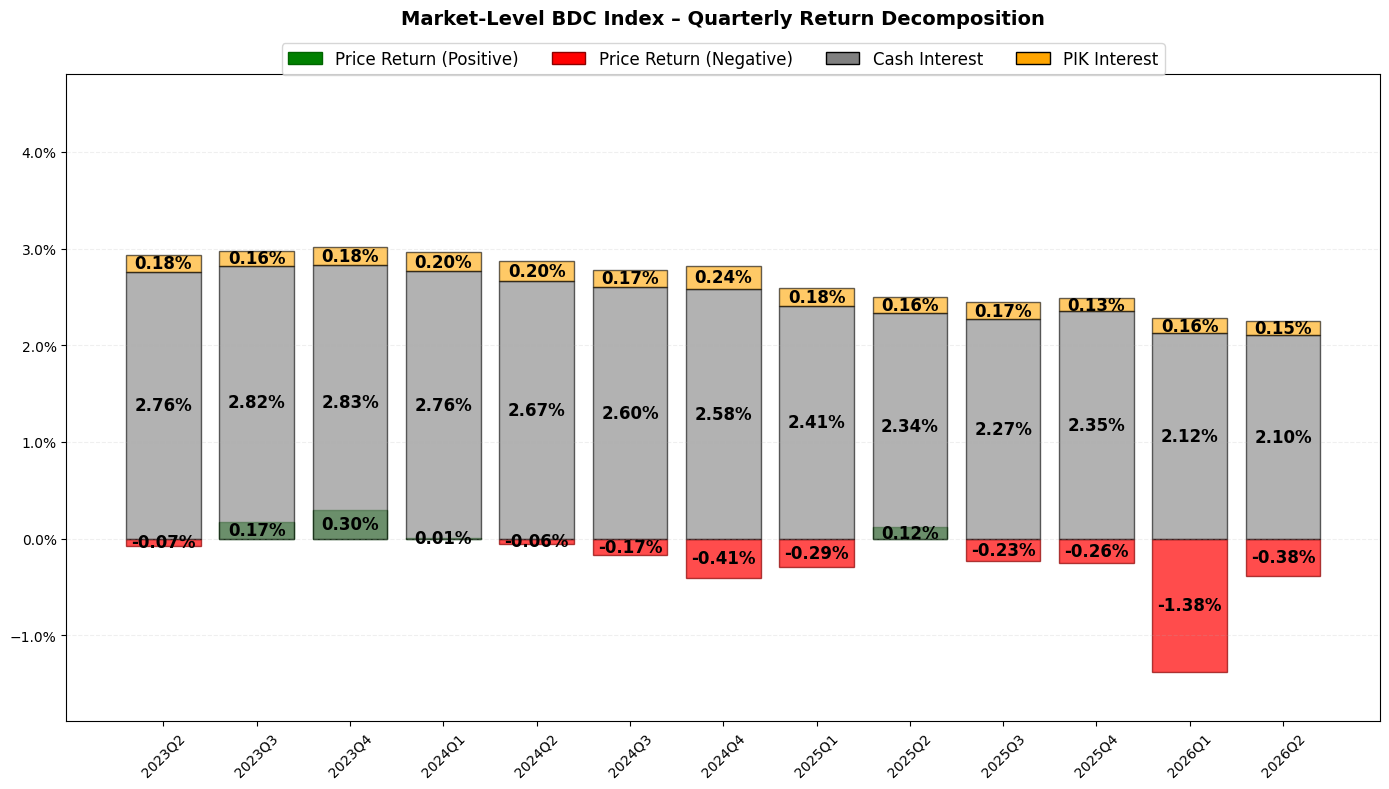

In [18]:
df_decomp = aggregate_return_decomposition(df, safe_div)
df_decomp_pd = df_decomp.to_pandas()

plot_quarterly_return_decomposition(
    df_decomp_pd,
    title="Market-Level BDC Index – Quarterly Return Decomposition\n"
)

## Get Return Decomposition for a particular Sector
#### No need to run this for index construction of the main index

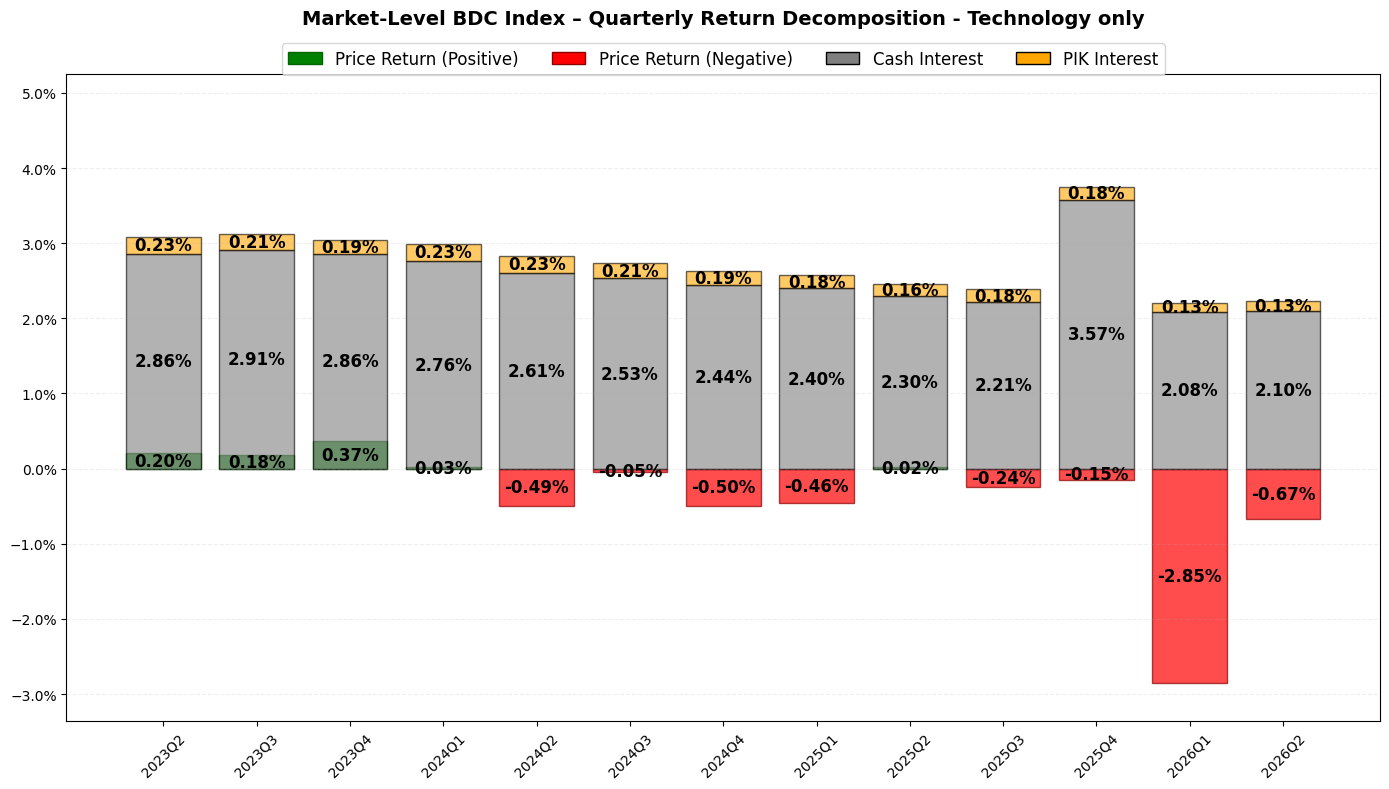

In [19]:
SECTOR = "Technology"
df_sector = df.filter(
    pl.col("sector").is_in([SECTOR])
)
df_sector = compute_market_weights(df_sector, safe_div=safe_div)
df_decomp = aggregate_return_decomposition(df_sector, safe_div)
df_decomp_pd = df_decomp.to_pandas()

plot_quarterly_return_decomposition(
    df_decomp_pd,
    title=f"Market-Level BDC Index – Quarterly Return Decomposition - {SECTOR} only\n"
)

## Get Return Decomposition for SENIOR LOANS
#### No need to run this for index construction of the main index

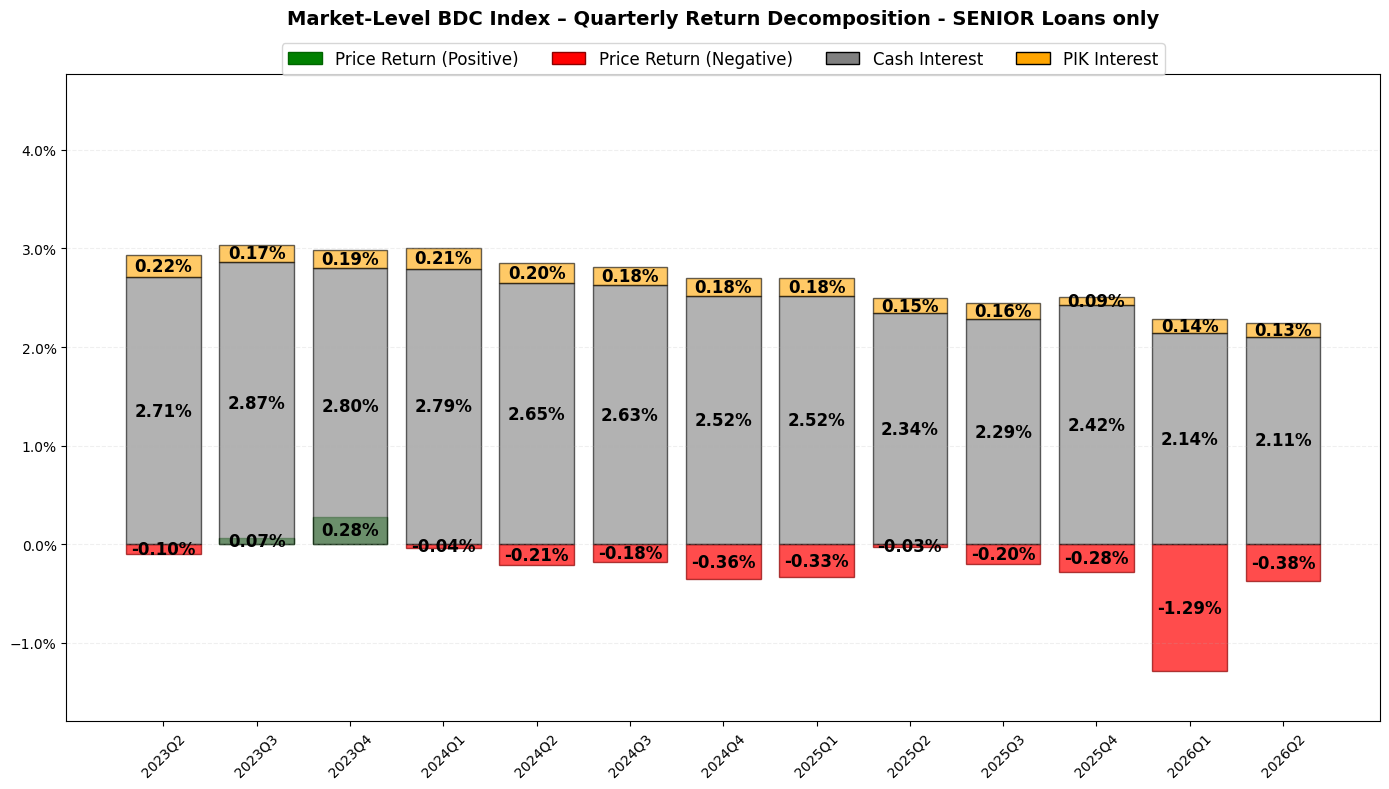

In [20]:
senior_loans_cols = ["SENIOR_SECURED_1L","SENIOR_SECURED_2L","SENIOR_UNSECURED","SENIOR_SECURED_UNSPEC","UNITRANCHE"]
df_loans = df.filter(
    pl.col("instrument_seniority").is_in(senior_loans_cols)
)
df_loans = compute_market_weights(df_loans, safe_div=safe_div)
df_decomp = aggregate_return_decomposition(df_loans, safe_div)
df_decomp_pd = df_decomp.to_pandas()
plot_quarterly_return_decomposition(
    df_decomp_pd,
    title=f"Market-Level BDC Index – Quarterly Return Decomposition - SENIOR Loans only\n"
)

In [21]:
index_mkt_flow = compute_flow_based_market_index(df)
index_mkt_flow_pd = index_mkt_flow.to_pandas()
index_mkt_flow_pd

,cal_q,IndexReturn,IndexLevel,IndexName
0,2023Q1,0.042837,104.283678,Flow-based (Market Investment-weighted)
1,2023Q2,0.028651,107.271554,Flow-based (Market Investment-weighted)
2,2023Q3,0.031477,110.648089,Flow-based (Market Investment-weighted)
3,2023Q4,0.033070,114.307230,Flow-based (Market Investment-weighted)
4,2024Q1,0.029739,117.706609,Flow-based (Market Investment-weighted)
5,2024Q2,0.028096,121.013663,Flow-based (Market Investment-weighted)
6,2024Q3,0.026113,124.173739,Flow-based (Market Investment-weighted)
7,2024Q4,0.024097,127.165953,Flow-based (Market Investment-weighted)
8,2025Q1,0.022960,130.085687,Flow-based (Market Investment-weighted)
9,2025Q2,0.026164,133.489304,Flow-based (Market Investment-weighted)


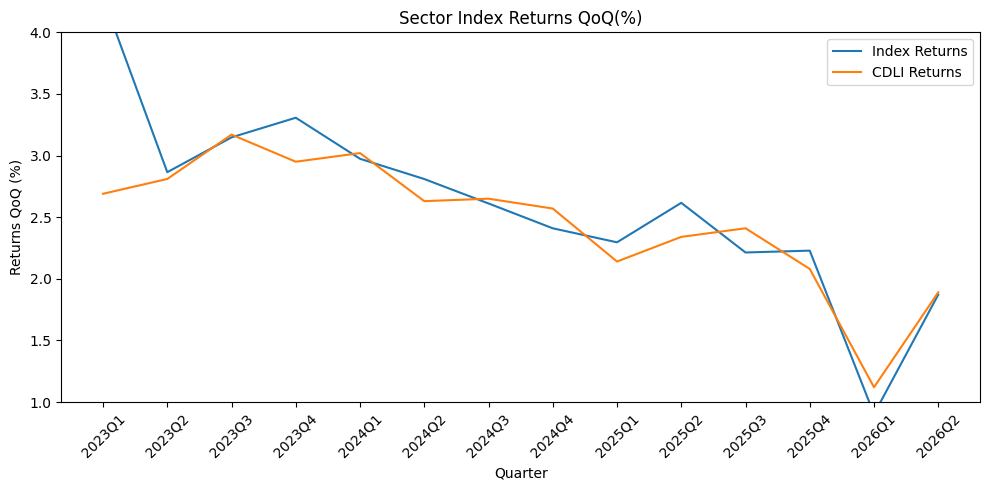

In [22]:
plot_index_vs_cdli_returns(
    index_df=index_mkt_flow,
    cdli_csv_path=cdli_csv_path
)

## Plot CDLI-S with Index Senior Loans
#### No need to run this for index construction of the main index

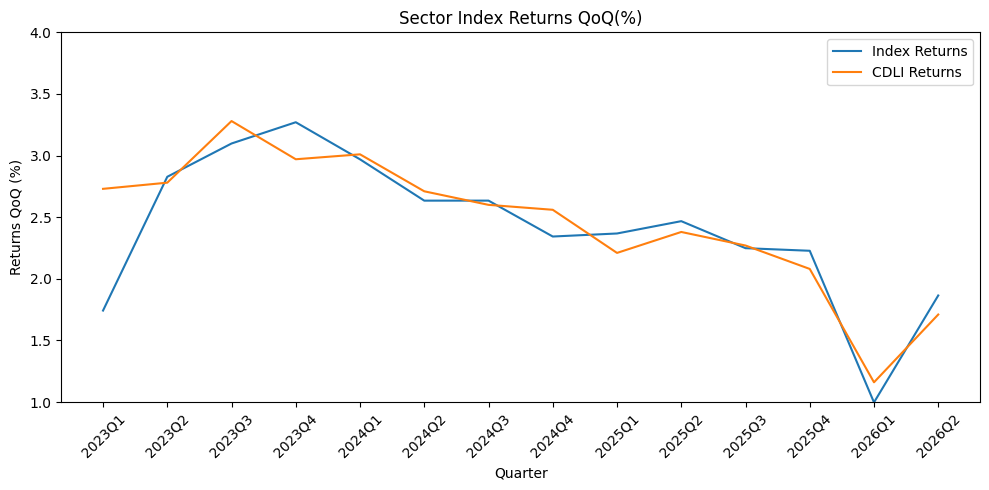

In [23]:
index_mkt_flow_loans = compute_flow_based_market_index(df_loans)
plot_index_vs_cdli_returns(
    index_df=index_mkt_flow_loans,
    cdli_csv_path=cdli_s_csv_path
)

In [24]:
annual_return, vol_a = compute_annualized_return_and_vol(
    returns=index_mkt_flow["IndexReturn"],
    periods_per_year=4,
    num_years=len(index_mkt_flow["IndexReturn"]) / 4,  # derive from actual data span, not a fixed constant
)
annual_return, vol_a

(0.1084289644509786, 0.01541036001577741)

In [25]:
quarterly_rates = load_quarterly_rates(rates_file)
quarterly_rates

Rate Type,EFFR,SOFR,cal_q
0,4.091905,4.065714,2022Q4
1,4.521935,4.498871,2023Q1
2,4.987302,4.967742,2023Q2
3,5.262381,5.236984,2023Q3
4,5.330000,5.321774,2023Q4
5,5.330000,5.314426,2024Q1
6,5.330000,5.318571,2024Q2
7,5.267500,5.277812,2024Q3
8,4.656613,4.678710,2024Q4
9,4.330000,4.328197,2025Q1


In [26]:
plot_df = build_quarterly_comparison_df(
    quarterly_rates,
    index_mkt_flow,
    cdli_csv_path
)
plot_df

,Quarter,EFFR_avg,SOFR_avg,IndexReturn,CDLI_Return
0,2022Q4,0.010230,0.010164,NaN,NaN
1,2023Q1,0.011305,0.011247,0.042837,0.0269
2,2023Q2,0.012468,0.012419,0.028651,0.0281
3,2023Q3,0.013156,0.013092,0.031477,0.0317
4,2023Q4,0.013325,0.013304,0.033070,0.0295
5,2024Q1,0.013325,0.013286,0.029739,0.0302
6,2024Q2,0.013325,0.013296,0.028096,0.0263
7,2024Q3,0.013169,0.013195,0.026113,0.0265
8,2024Q4,0.011642,0.011697,0.024097,0.0257
9,2025Q1,0.010825,0.010820,0.022960,0.0214


In [27]:
corr, te_q, te_a = compute_tracking_error(plot_df)
corr,te_a

(             IndexReturn  CDLI_Return
 IndexReturn     1.000000     0.961689
 CDLI_Return     0.961689     1.000000,
 0.0035811369248796403)

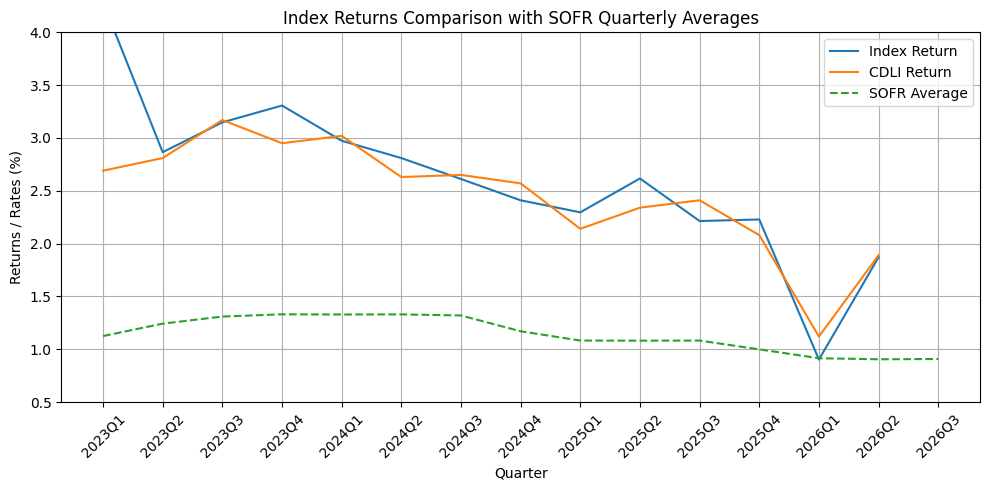

In [28]:
plot_index_cdli_sofr(plot_df)

## Correlation & Tracking Error - Senior Loans Index vs CDLI-S
#### No need to run this for index construction of the main index

In [29]:
plot_df_loans = build_quarterly_comparison_df(
    quarterly_rates,
    index_mkt_flow_loans,
    cdli_s_csv_path
)
plot_df_loans

,Quarter,EFFR_avg,SOFR_avg,IndexReturn,CDLI_Return
0,2022Q4,0.010230,0.010164,NaN,NaN
1,2023Q1,0.011305,0.011247,0.017422,0.0273
2,2023Q2,0.012468,0.012419,0.028278,0.0278
3,2023Q3,0.013156,0.013092,0.030979,0.0328
4,2023Q4,0.013325,0.013304,0.032704,0.0297
5,2024Q1,0.013325,0.013286,0.029693,0.0301
6,2024Q2,0.013325,0.013296,0.026341,0.0271
7,2024Q3,0.013169,0.013195,0.026344,0.0260
8,2024Q4,0.011642,0.011697,0.023430,0.0256
9,2025Q1,0.010825,0.010820,0.023677,0.0221


In [30]:
corr_loans, te_q_loans, te_a_loans = compute_tracking_error(plot_df_loans)
corr_loans, te_a_loans

(             IndexReturn  CDLI_Return
 IndexReturn     1.000000     0.965277
 CDLI_Return     0.965277     1.000000,
 0.003068983661934603)

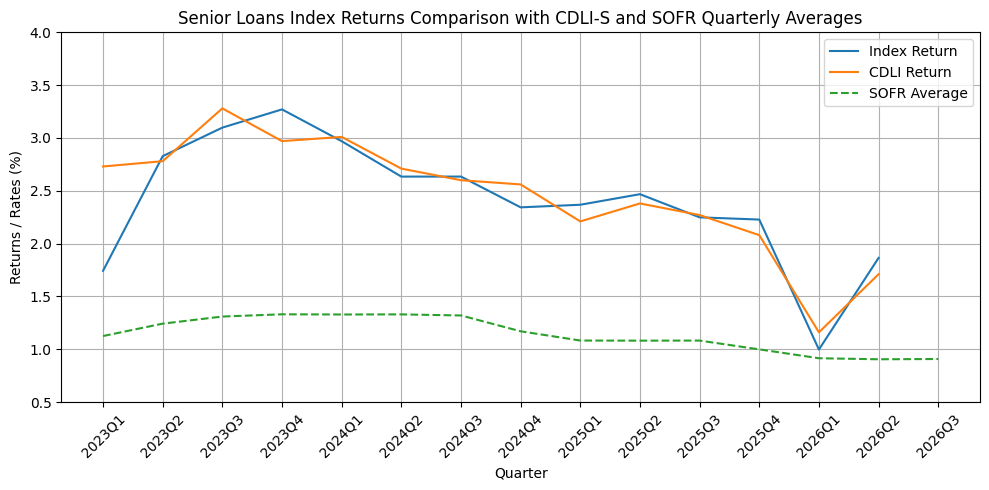

In [31]:
plot_index_cdli_sofr(
    plot_df_loans,
    title="Senior Loans Index Returns Comparison with CDLI-S and SOFR Quarterly Averages"
)

In [32]:
a = (
    df.group_by("cal_q")
      .agg(
          pl.col("FV_prev").null_count().alias("null_count"),
          (pl.col("FV_prev").null_count() / pl.len()).alias("null_proportion"),
          pl.col("cik").n_unique().alias("unique_ciks")
      )
)

a = a.to_pandas()
a

,cal_q,null_count,null_proportion,unique_ciks
0,2023Q2,6840,0.324263,104
1,2024Q1,11062,0.382398,130
2,2026Q2,15695,0.522348,101
3,2025Q3,20409,0.488511,161
4,2023Q4,11985,0.454632,125
5,2025Q1,16708,0.451690,145
6,2025Q2,17143,0.426814,159
7,2025Q4,36375,0.812450,165
8,2023Q3,8916,0.374449,117
9,2026Q1,26625,0.578918,167
